In [1]:
from __future__ import annotations

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pathlib import Path


# -----------------------------
# Paths
# -----------------------------

DATA_PATH = Path(
    "/home/server/pi/homes/queenl/projects/climate-risk-dc/data"
)

# IM3 PNNL data-center dataset
IM3_FILE = DATA_PATH / "data_centers_im3_pnnl" / "im3_open_source_data_center_atlas_v2026.02.09.gpkg"

# Supplemental CSV data-center points
CSV_FILE = DATA_PATH / "data_centers_im3_pnnl" / "im3_open_source_data_center_atlas_v2026.02.09.csv"

# Public water service areas
WATER_FILE = (
    DATA_PATH
    / "public_water_sources"
    / "WSA_v1"
    / "WSA_v1.shp"
)

# Watershed boundaries (USGS WBD)
WATERSHED_FILE = (
    DATA_PATH
    / "watershed_boundaries"
    / "WBD_National_GDB.gdb"
)


# -----------------------------
# Coordinate systems
# -----------------------------

CRS_GEOGRAPHIC = "EPSG:4326"


# -----------------------------
# Map settings
# -----------------------------

OREGON_EXTENT = [
    -125,   # west
    -116,   # east
    42,     # south
    46.5    # north
]

MAP_PROJECTION = ccrs.PlateCarree()


# -----------------------------
# Plot styles
# -----------------------------

LAYER_STYLES = {
    "watershed": {
        "facecolor": "none",
        "edgecolor": "gray",
        "alpha": 0.6,
        "linewidth": 0.5,
        "label": "Watershed",
    },
    "water": {
        "facecolor": "lightsteelblue",
        "edgecolor": "steelblue",
        "alpha": 0.35,
        "linewidth": 0.3,
        "label": "Public water service area",
    },
    "campus": {
        "facecolor": "orange",
        "edgecolor": "darkorange",
        "alpha": 0.45,
        "linewidth": 0.4,
        "label": "Campus",
    },
    "building": {
        "facecolor": "red",
        "edgecolor": "darkred",
        "alpha": 0.45,
        "linewidth": 0.4,
        "label": "Building",
    },
    "point": {
        "color": "blue",
        "size": 35,
        "label": "Point",
    },
    "csv": {
        "color": "black",
        "size": 15,
        "label": "CSV",
    },
}

In [2]:
def load_datasets(
    watershed_level: str = "WBDHU8"
) -> dict[str, gpd.GeoDataFrame]:
    """
    Load IM3 data centers, public water service areas,
    and watershed boundaries for Oregon.
    """

    datasets = {}

    # -----------------------------
    # IM3 PNNL layers
    # -----------------------------

    for layer in ["point", "building", "campus"]:

        gdf = gpd.read_file(
            IM3_FILE,
            layer=layer
        )

        if gdf.crs is None:
            gdf = gdf.set_crs(CRS_GEOGRAPHIC)

        datasets[layer] = gdf.to_crs(CRS_GEOGRAPHIC)


    # -----------------------------
    # CSV point data
    # -----------------------------

    df = pd.read_csv(CSV_FILE)

    geometry = gpd.points_from_xy(
        df["lon"],
        df["lat"]
    )

    datasets["csv"] = gpd.GeoDataFrame(
        df,
        geometry=geometry,
        crs=CRS_GEOGRAPHIC
    )


    # -----------------------------
    # Public water service areas
    # -----------------------------

    water = gpd.read_file(WATER_FILE)

    if water.crs is None:
        water = water.set_crs(CRS_GEOGRAPHIC)

    datasets["water"] = water.to_crs(CRS_GEOGRAPHIC)


    # -----------------------------
    # Watersheds
    # -----------------------------

    available_layers = set(
        gpd.list_layers(WATERSHED_FILE)["name"]
    )

    if watershed_level not in available_layers:
        raise ValueError(
            f"Unsupported watershed layer '{watershed_level}'. "
            f"Available layers: {sorted(available_layers)}"
        )

    watersheds = gpd.read_file(
        WATERSHED_FILE,
        layer=watershed_level
    )

    # Filter Oregon
    if "states" in watersheds.columns:
        watersheds = watersheds[
            watersheds["states"].str.contains("OR")
        ]

    if watersheds.crs is None:
        watersheds = watersheds.set_crs(CRS_GEOGRAPHIC)

    datasets["watershed"] = watersheds.to_crs(CRS_GEOGRAPHIC)


    return datasets

In [25]:
def plot_dataset(datasets: dict[str, gpd.GeoDataFrame]) -> None:
    """Plot Oregon data centers, water systems, and watershed boundaries."""

    fig, ax = plt.subplots(
        figsize=(8, 10),
        dpi=150,
        subplot_kw={
            "projection": MAP_PROJECTION
        }
    )

    ax.set_extent(
        OREGON_EXTENT,
        crs=MAP_PROJECTION
    )


    # Background
    ax.add_feature(
        cfeature.LAND,
        facecolor="whitesmoke"
    )

    ax.add_feature(
        cfeature.OCEAN,
        facecolor="lightblue"
    )

    ax.add_feature(
        cfeature.STATES,
        linewidth=0.6
    )

    ax.add_feature(
        cfeature.COASTLINE,
        linewidth=0.6
    )


    # Watershed boundaries (bottom overlay)
    if "watershed" in datasets:
        datasets["watershed"].plot(
            ax=ax,
            transform=MAP_PROJECTION,
            **{
                k: v for k, v in LAYER_STYLES["watershed"].items()
                if k != "label"
            }
        )


    # Public water areas
    if "water" in datasets:
        datasets["water"].plot(
            ax=ax,
            transform=MAP_PROJECTION,
            **{
                k: v for k, v in LAYER_STYLES["water"].items()
                if k != "label"
            }
        )


    # Infrastructure polygons
    #for layer in ["campus", "building"]:

    #    if layer in datasets:

    #        datasets[layer].plot(
    #            ax=ax,
    #            transform=MAP_PROJECTION,
    #            **{
    #                k: v for k, v in LAYER_STYLES[layer].items()
    #                if k != "label"
    #            }
    #        )


    # Point layers
    for layer in ["csv"]:#"point", 

        if layer in datasets:

            gdf = datasets[layer]

            ax.scatter(
                gdf.geometry.x,
                gdf.geometry.y,
                transform=MAP_PROJECTION,
                s=LAYER_STYLES[layer]["size"],
                c=LAYER_STYLES[layer]["color"],
                alpha=0.8,
                edgecolor="white",
                linewidth=0.2
            )


    ax.set_title(
        "IM3 Data Centers, Public Water Service Areas, and Watersheds - Oregon",
        fontsize=13,
        weight="bold"
    )

    plt.tight_layout()

    plt.show(fig)

In [4]:
datasets = load_datasets()

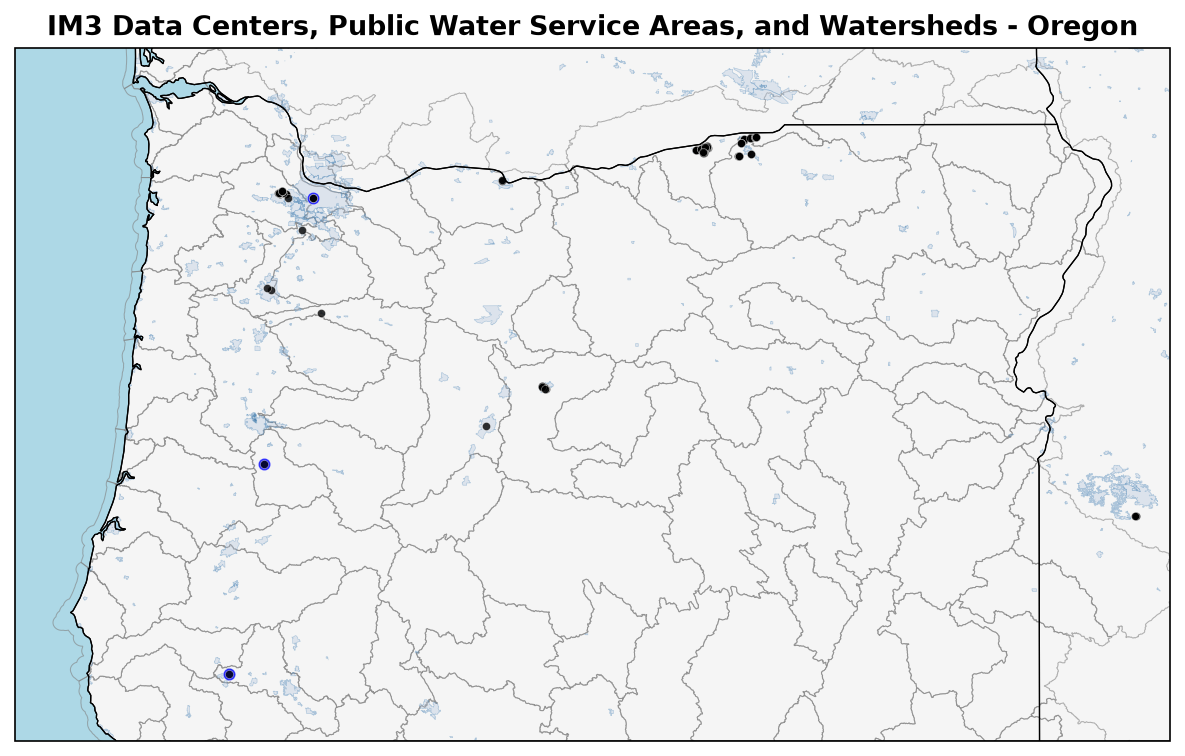

In [7]:
plot_dataset(datasets)

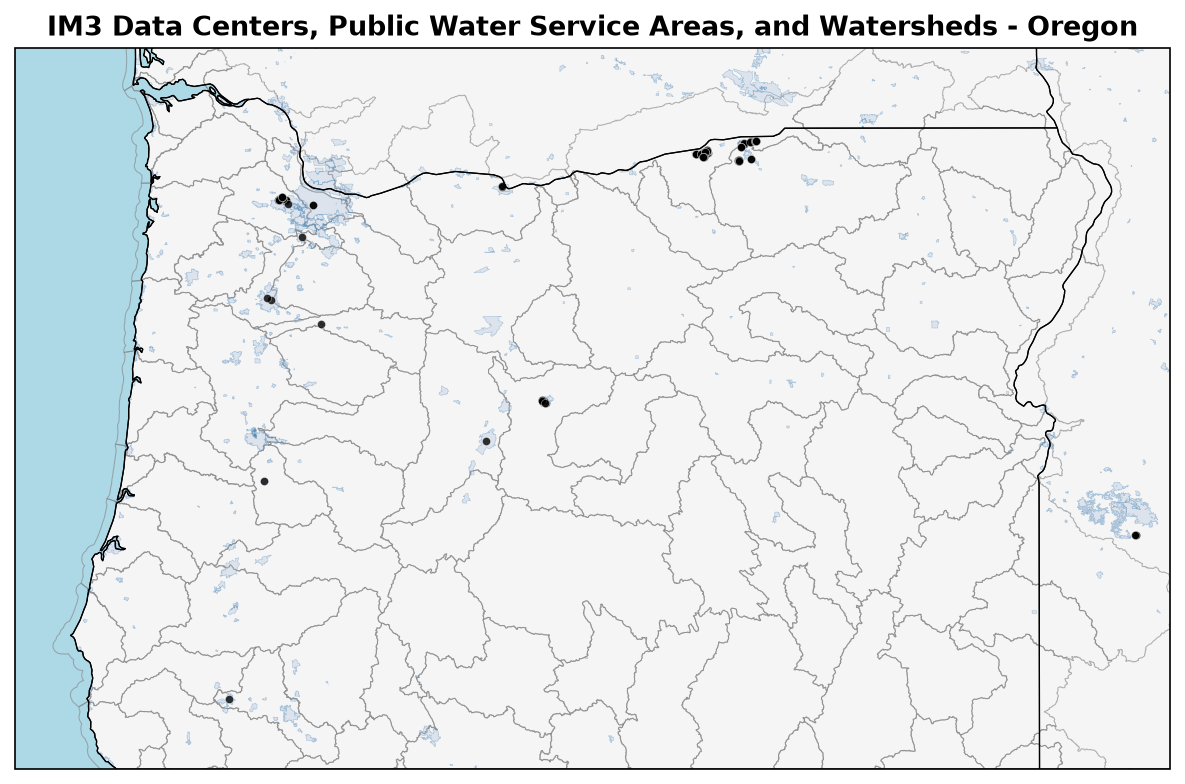

In [26]:
plot_dataset(datasets)

In [10]:
oregon_csv = datasets['csv'][datasets['csv']['state']=='Oregon']


In [22]:
oregon_csv['sqft'].min()

np.float64(2521.0)

In [18]:
len(oregon_csv['id'].unique())

109

(45.75, 45.95)

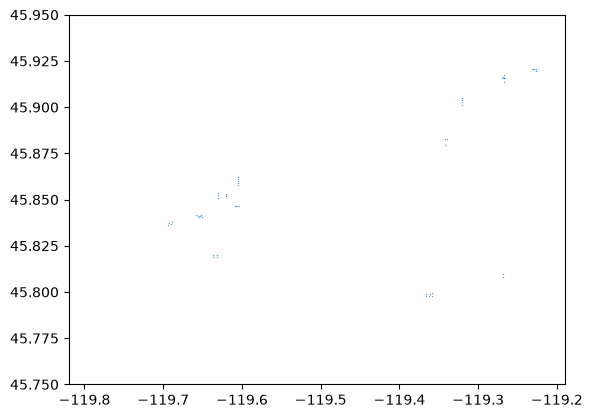

In [20]:
plt.scatter(
                oregon_csv.geometry.x,
                oregon_csv.geometry.y,
                alpha=0.8,
                edgecolor="white",
                linewidth=0.2,
                s=1
            )

plt.xlim(-119.82,-119.19)
plt.ylim(45.75,45.95)